In [4]:
%cd /scratch/users/baranh/deep_0/SpherePackings
import os
import numpy as np
import torch
import time
import math
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import configparser
from diffuse_boost.spheres_in_cube import data_load_save
from datetime import datetime
from diffuse_boost.spheres_in_cube.plot_data_points import plot_3d
import diffuse_boost.spheres_in_Rd.data_evaluation as data_evaluation
from diffuse_boost.spheres_in_Rd.data_evaluation import plot_evaluations

from torchdiffeq import odeint
import schedulefree
from x_transformers import ContinuousTransformerWrapper, Encoder

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.utils import ModelWrapper
from flow_matching.solver import ODESolver
from torch.distributions import Independent, Normal

from diffuse_boost import cfg

/scratch/users/baranh/deep_0/SpherePackings


In [5]:
# Continuous flow matching path with CondOT (linear) scheduler
FM_PATH = AffineProbPath(scheduler=CondOTScheduler())

# Model 

In [16]:
class FlowSetTransformer(nn.Module):
    class TimeEmbedFourier(nn.Module):
        def __init__(
            self,
            out_dim: int,
            fourier_dim: int,
            hidden: int,
            sigma: float = 1.0,
            include_poly: bool = True,
        ):
            super().__init__()
            fourier_dim = max(16, fourier_dim)
            # fixed (non-trainable) Fourier frequencies
            self.register_buffer("freqs", torch.randn(fourier_dim) * sigma, persistent=False)
            self.include_poly = include_poly
            in_dim = 2 * fourier_dim
            if include_poly:
                in_dim += 4  # [t, t^2, t^3, log(1+t)]
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.SiLU(),
                nn.Linear(hidden, out_dim),
            )

        def forward(self, t: torch.Tensor) -> torch.Tensor:
            # t: (B,) or (B,1) -> (B,)
            if t.ndim == 2:
                assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
                t = t[:, 0]
            t = t.contiguous()
            # Fourier features
            angles = (t[:, None] * self.freqs[None, :]) * (2.0 * math.pi)
            sin_feat = torch.sin(angles)
            cos_feat = torch.cos(angles)
            feats = [sin_feat, cos_feat]
            if self.include_poly:
                t1 = t
                t2 = t1 * t1
                t3 = t2 * t1
                tlog = torch.log1p(t1.clamp_min(0))  # stable near 0
                feats += [t1[:, None], t2[:, None], t3[:, None], tlog[:, None]]

            h = torch.cat(feats, dim=-1)
            return self.net(h)

    def __init__(self, d: int = 3, **st_kwargs):
        super().__init__()
        self.d = d
        model_dim = int(st_kwargs.get("dim_hidden", 512))
        heads = int(st_kwargs.get("num_heads", 8))
        depth = int(st_kwargs.get("num_isab", st_kwargs.get("depth", 6)))
        ff_mult = float(st_kwargs.get("ff_mult", 4.0))
        attn_do = float(st_kwargs.get("attn_dropout", 0.1))
        ff_do = float(st_kwargs.get("ff_dropout", 0.1))
        dim_time = int(st_kwargs.get("dim_time", max(64, 4 * d)))
        time_F = int(st_kwargs.get("time_fourier_dim", max(16, dim_time // 2)))
        time_hid = int(st_kwargs.get("time_hidden", 2 * dim_time))
        sigma = float(st_kwargs.get("time_fourier_sigma", 1.0))

        #conditioning setup
        cond_dim_in  = int(st_kwargs.get("cond_dim_in", 4))   # 0 keeps old behavior
        cond_hidden  = int(st_kwargs.get("cond_hidden", max(64, dim_time)))
        self.uses_cond = cond_dim_in > 0

        # Time embedding (B,) / (B,1) -> (B, dim_time)
        self.time_emb = self.TimeEmbedFourier(
            out_dim=dim_time, fourier_dim=time_F, hidden=time_hid,
            sigma=sigma, include_poly=True
        )

        if self.uses_cond:
            self.cond_mlp = nn.Sequential(
                nn.Linear(cond_dim_in, cond_hidden),
                nn.SiLU(),
                nn.Linear(cond_hidden, cond_hidden)
            )
            dim_cond = cond_hidden
        else:
            self.cond_mlp = None
            dim_cond = 0

        # per-point coords + time + (optional) cond
        self.token_in = nn.Linear(d + dim_time + dim_cond, model_dim)

        # FiLM generator takes [time ⊕ cond] jointly, so timing can steer modulation
        self.film_in_dim = dim_time + dim_cond
        self.timecond_to_film = nn.Sequential(
            nn.SiLU(),
            nn.Linear(self.film_in_dim, 2 * model_dim)
        )

        self.encoder = Encoder(
            dim = model_dim,
            depth=depth,
            heads=heads,
            layer_dropout= 0.1,
            #rotary_pos_emb = True,
            attn_dropout = attn_do, 
            ff_dropout = ff_do,
            use_rmsnorm=True,
            ff_glu=True,
            ff_no_bias=True,
            attn_flash=True
        )

        self.token_out = nn.Linear(model_dim, d)
        # Zero-init output to start near 0 velocity (stabilizes FM training)
        nn.init.zeros_(self.token_out.weight)
        nn.init.zeros_(self.token_out.bias)

    def forward(self, t: torch.Tensor, x: torch.Tensor, cond: torch.Tensor = None) -> torch.Tensor:
        """
        t:    (B,) or (B,1)
        x:    (B, d, N)
        cond: (B, C) or None
        ->    (B, d, N)
        """
        B, d, N = x.shape
        assert d == self.d, f"Expected d={self.d}, got {d}"
        device = x.device
        t = t.to(device=device, dtype=x.dtype)
        if t.ndim == 2:
            assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
            t_1d = t[:, 0]
        else:
            t_1d = t
        t_embed = self.time_emb(t_1d)  # (B, dim_time)
        if self.uses_cond:
            if cond is None:
                # for classifier-free guidance: treat None as zeros
                cond = torch.zeros(B, self.cond_mlp[0].in_features, device=device, dtype=x.dtype)
            else:
                cond = cond.to(device=device, dtype=x.dtype)
            c_embed = self.cond_mlp(cond)        # (B, dim_cond)
        else:
            c_embed = None

        tokens = x.permute(0, 2, 1).contiguous()            # (B, N, d)
        if c_embed is not None:
            tc = torch.cat([t_embed, c_embed], dim=-1)      # (B, dim_time+dim_cond)
            tc_rep = tc[:, None, :].expand(B, N, -1)        # (B, N, ...)
            h = torch.cat([tokens, tc_rep], dim=-1)         # (B, N, d + dim_time + dim_cond)
            film_in = tc                                     # (B, dim_time+dim_cond)
        else:
            t_rep = t_embed[:, None, :].expand(B, N, -1)    # (B, N, dim_time)
            h = torch.cat([tokens, t_rep], dim=-1)          # (B, N, d + dim_time)
            film_in = t_embed                                # (B, dim_time)
        h = self.token_in(h)                                 # (B, N, model_dim)
        # FiLM modulation from joint [time ⊕ cond]
        gamma_beta = self.timecond_to_film(film_in)          # (B, 2*model_dim)
        gamma, beta = gamma_beta.chunk(2, dim=-1)            # (B, model_dim) each
        gamma = gamma[:, None, :]
        beta  = beta[:, None, :]
        h = h * (1 + gamma) + beta

        h = self.encoder(h)                                  # (B, N, model_dim)
        out = self.token_out(h).permute(0, 2, 1).contiguous()# (B, d, N)
        return out

# Training

In [34]:
_TRI_CACHE = {}
def distance_penalty(output, radius, margin=0.0, beta=10.0, p=2, q=0.05, eps=1e-12):
    B, d, N = output.shape
    coords = output.permute(0, 2, 1)                  # (B, N, d)
    dmat = torch.cdist(coords, coords) + eps
    r = torch.as_tensor(radius, device=output.device, dtype=output.dtype)
    m = torch.as_tensor(margin, device=output.device, dtype=output.dtype)
    gap = (2 * r + m) - dmat                          # >0 means violation / near-violation
    v = F.softplus(beta * gap) / beta                 # smooth hinge
    key = (output.device, N)
    tri = _TRI_CACHE.get(key)
    if tri is None:
        tri = torch.triu_indices(N, N, offset=1, device=output.device)
        _TRI_CACHE[key] = tri
    v = v[:, tri[0], tri[1]]                          # (B, pairs)
    if p != 1:
        v = v.pow(p)
    #return v.mean() 
    #OR
    #top-k over pairs per sample
    Pairs = v.size(1)
    k = max(1, int(q * Pairs))
    topk, _ = torch.topk(v, k=k, dim=1, largest=True, sorted=False)
    return topk.mean()


def _box_clamp(x, r, L):
    # Snap to [r, L-r] per coordinate
    return x.clamp(r, L - r)

def _time_grid_dense_tail(device, steps=201, gamma=3.0):
    # Denser near t=0 (data end). Integrate 1-->0.
    s = torch.linspace(0.0, 1.0, steps=steps, device=device)
    t = s**gamma
    return torch.flip(t, dims=(0,))

def _sample_t_near_zero(B, device, scale=1e-3):
    # Tiny t concentrated near 0 for penalties that should act "at the end"
    # (square to bias even closer to 0)
    return (scale * torch.rand(B, device=device))**2


def _sample_x1_box_faces_per_batch(x0, r, L=1.0, p_face_batch=None, jitter=5e-3):
    """
    x0: (B,d,N) (only for shape/device)
    p_face_batch: (B,) per-sample prob a token sits on a face
    """
    B, d, N = x0.shape
    u = torch.rand_like(x0) * (L - 2*r) + r
    if p_face_batch is not None:
        mask = (torch.rand(B, N, device=x0.device) < p_face_batch[:, None])
        axis = torch.randint(0, d, (B, N), device=x0.device)
        side = torch.randint(0, 2, (B, N), device=x0.device)  # 0->r, 1->L-r
        face_val = torch.where(side == 0, torch.full((), r, device=x0.device),
                                         torch.full((), L - r, device=x0.device))
        ar = torch.arange(B, device=x0.device)[:, None].expand(B, N)
        nr = torch.arange(N, device=x0.device)[None, :].expand(B, N)
        u[ar, axis, nr] = torch.where(mask, face_val, u[ar, axis, nr])
    u = (u + jitter * torch.randn_like(u)).clamp(r, L - r)
    return u


def save_with_plot(model, optimizer, history, epoch, params, sec):
    save_dir = sec
    os.makedirs(save_dir, exist_ok=True)
    loss = history[-1,2]
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    name = f"flow_model_loss={loss:.4f}_{ts}.pth"
    path = os.path.join(save_dir, name)
    data_load_save.save_model(path, model, optimizer, epoch, params)

    plt.figure(figsize=(12,6))
    plt.plot(history[:,0], label="Flow MSE Loss")
    plt.plot(history[:,1], label="Distance Penalty")
    plt.plot(history[:,2], label="Total Loss")
    plt.yscale('log')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.grid()
    plt.savefig(os.path.join(save_dir, f"flow_loss_{ts}.png"))

def _make_time_grid(device, kind="data_focus", steps=101, gamma=2.0, tau=0.1):
    s = torch.linspace(0.0, 1.0, steps=steps, device=device)

    if kind == "uniform":
        t = s
    elif kind == "data_focus":
        t = s**gamma
    elif kind == "noise_focus":
        t = 1.0 - torch.exp(-s / tau)
    else:
        raise ValueError(kind)
    return torch.flip(t, dims=(0,))  # integrate from 1-->0

def sample_t(B, device, small_t_weight=0.5, gamma=2.0):
    s = torch.rand(B, device=device)
    t_small = s**gamma
    use_small = (torch.rand(B, device=device) < small_t_weight).float()
    return use_small * t_small + (1 - use_small) * s


def train_flow_model(
    model, optimizer, loader, num_epochs,
    sphere_radius, mse_strength, dist_strength,
    clip_min, clip_max, device, params, save_path
):
    model.train().to(device)
    optimizer.train()
    mse = nn.MSELoss()
    history, best = [], 1e9

    bmin = torch.tensor(sphere_radius, device=device)
    bmax = torch.tensor(clip_max - sphere_radius, device=device)
    center = (bmin + bmax)*0.5
    half = (bmax - bmin)*0.5

    for epoch in tqdm(range(num_epochs), desc="Training"):
        ep_losses=[]
        ratio = 0.5 * (1 - np.cos(np.pi * min(1.0, epoch / (0.5 * num_epochs))))
        for x_0, cond in loader:
            x_0 = x_0.to(device)
            cond = cond.to(device)
            B = x_0.size(0)
            cond_in = cond #None if torch.rand(()) < 0.1 else cond
                
            # source x_1 uses per-sample p_face from cond
            p_face_batch = cond[:, 2].clamp(0, 1)     # (B,)
            x_1 = _sample_x1_box_faces_per_batch(x_0, sphere_radius, L=clip_max,
                                                 p_face_batch=p_face_batch, jitter=5e-3)
            t_in = sample_t(x_0.size(0), device=device, small_t_weight=0.5, gamma=2.0) #(B,1)
            path_sample = FM_PATH.sample(t=t_in, x_0=x_0, x_1=x_1)
            x_t  = path_sample.x_t
            dx_t = path_sample.dx_t         # target velocity along the path

            u_pred = model(t_in.squeeze(-1), _box_clamp(x_t, sphere_radius, clip_max), cond=cond_in)
            
            # Flow-matching loss
            loss_fm = mse(u_pred, dx_t)

            #penalty
            eps_t = 1e-3
            with torch.no_grad():
                sch0 = FM_PATH.scheduler(t_in)  # t_in: (B,)
                sch1 = FM_PATH.scheduler((t_in + eps_t).clamp_max(1.0))
            alpha_dot = ((sch1.alpha_t - sch0.alpha_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            sigma_dot = ((sch1.sigma_t - sch0.sigma_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            alpha_dot_safe = alpha_dot.sign() * alpha_dot.abs().clamp_min(1e-6)
            x0_proj = (u_pred - sigma_dot * x_1) / alpha_dot_safe
            #OR
            #x0_proj = x0_pred.clamp(sphere_radius, clip_max - sphere_radius)
            #OR
            #x0_proj = center + half * torch.tanh((x0_pred - center) / (half + 1e-6))
            #pen = distance_penalty(x0_proj, sphere_radius)
            #OR

            pen = distance_penalty(
                x0_proj, sphere_radius,
                margin=0.02 * sphere_radius,
                beta=80.0,
                p=2,
                q=0.20 
            )

            loss = mse_strength * loss_fm + dist_strength * ratio * pen

            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_losses.append([loss_fm.item(), pen.item(), loss.item()])

        avg = np.mean(ep_losses, axis=0)
        history.append(avg)
        print(f"Epoch {epoch+1}/{num_epochs} | FM={avg[0]:.4f} Pen={avg[1]:.4f} Tot={avg[2]:.4f}")

    save_with_plot(model, optimizer, np.array(history), num_epochs-1, params, save_path)
    return model, np.array(history)


@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, cond_loader=None):
    """
    Physics-Constrained Flow Matching (PCFM) for hard spheres (radius r) in a box [r, L-r]^d.
    Returns:
        np.ndarray of shape (num_samples, d, N)
    """

    #Hyperparameters
    N_steps = 40          # outer steps in tau (0 -> 1)
    ode_method = 'midpoint'
    ode_step_cap = 0.05        # max internal step size for ODESolver (in t-units)
    jitter = 5e-3        # initial x1 jitter
    eps_nrm = 1e-6        # normal jitter relative to r (for stable normals)
    # Terminal projection (Gauss-Newton)
    proj_outer_iters = 8           # GN iterations at terminal
    alpha_proj = 0.25        # step size for projection updates
    contact_q = 1.0         # fraction of strongest contacts to use (1.0 = all)
    wall_weight = 1.0         # add soft wall ghost constraints to avoid corner glue
    wall_margin = 0.05        # as fraction of diameter for wall proximity
    # Relaxed correction (prox) at tau'
    prox_iters = 10           # number of GD steps
    prox_step = 0.1         # step size for prox GD
    prox_lambda = 2.0         # constraint penalty
    # Final polish
    final_passes = 6
    tol_finish = 1e-8

    L = float(clip_max)
    r = float(sphere_radius)

    def _clamp_box(x):
        return x.clamp(r, L - r)

    # model expects t \in [1->0]
    class _FMVF:
        def __init__(self, mdl, cond):
            self.mdl, self.cond = mdl, cond
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond) if self.cond is not None else self.mdl(tb, x)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond):
        """ODESolve with learned field from tau_start to tau_end, mapped to model time t=1-tau."""
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)   # decreasing t as tau increases
        solver = ODESolver(velocity_model=_FMVF(model, cond))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box(x_end)

    def _active_overlap(x, for_stop=False):
        P = x.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)

        overlap = (2.0 * r - dist)                  # positive => penetrating
        B, N, _ = overlap.shape
        eye = torch.eye(N, device=x.device, dtype=torch.bool)[None]
        overlap = overlap.masked_fill(eye, 0.0)
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, margin_frac=0.05, scale=1.0):
        """Soft wall ghost constraints"""
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r)
        for ax in range(d):
            dl = u[:, ax, :] - r              # distance to low face along axis ax
            dh = (L - r) - u[:, ax, :]        # distance to high face
            near_low  = (dl < thr)
            near_high = (dh < thr)
            delta[:, ax, :] += torch.where(near_low,  (thr - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr - dh), 0.0)
        return scale * delta

    def _project_terminal(u):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box(u + alpha_proj * (delta_pairs + delta_walls))
        return u

    def _Jt_h_at_state(u_next):
        """
        Fast Approximatation J^T h(u_next): pairwise + wall residual gradients, shape (B,d,N).
        """
        overlap, n, eye = _active_overlap(u_next, for_stop=False)
        active = (overlap > 0) & (~eye)
        # pair contribution (same as GN but without 0.5 and without degree normalization)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        # wall contribution
        jt_walls = _wall_push(u_next, margin_frac=wall_margin, scale=1.0)  # inward normal
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond):
        # gradient steps
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            # evaluate v_theta at tau'
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond) if cond is not None else model(tb, u)
            u_next = _clamp_box(u + (1.0 - tau_prime) * v)

            jt_h = _Jt_h_at_state(u_next)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box(u - prox_step * grad)
        return u

    def _final_polish(u):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                break
            u = _project_terminal(u)
        return u

    model.eval()
    optimizer.eval()

    samples, remaining = [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None
    while remaining > 0:
        bs = min(batch_size, remaining)
        # conditioning batch (optional)
        if cond_iter is not None:
            try:
                x_dummy, cond = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond = next(cond_iter)
            cond = cond.to(device)
            if cond.size(0) > bs:
                cond = cond[:bs]
        else:
            cond = None

        # Initialize u0 at tau=0 (x1 in standard FM), then clamp inside box.
        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        u0 = _clamp_box(u0)
        u = u0.clone()

        # tau grid
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps
            #Forward shoot to tau=1 with learned field
            u1 = _ode_solve_with_model(u, tau, 1.0, cond)
            #Terminal projection Π_H
            u_proj = _project_terminal(u1)
            #Reverse OT
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond)

        # final polishing
        u = _final_polish(u)
        samples.append(u.cpu().numpy())
        remaining -= bs

    return np.concatenate(samples, axis=0)



class SpherePackingDataset(Dataset):
    def __init__(self, path, radius, box_len, tol=1e-4, chunk=256, scale_N=128):
        """
        path: torch file with tensor of shape (M, d, N)
        radius: sphere radius r
        box_len: cube side length L
        tol: face snapping tolerance for 'on-face' test
        chunk: chunk size for minsep precompute
        """
        data = torch.load(path)  # (M, d, N)
        assert data.ndim == 3, f"expected (M,d,N), got {tuple(data.shape)}"
        self.data = data.contiguous()
        self.M, self.d, self.N = self.data.shape
        self.r = float(radius)
        self.L = float(box_len)

        #p_face per sample
        near_r  = (self.data - self.r).abs() <= tol
        near_lr = (self.data - (self.L - self.r)).abs() <= tol
        on_face_any = (near_r | near_lr).any(dim=1)        # (M, N)
        p_face = on_face_any.float().mean(dim=1)           # (M,)

        #minsep per sample
        minsep = torch.empty(self.M, dtype=self.data.dtype)
        for s in range(0, self.M, chunk):
            e = min(self.M, s + chunk)
            xb = self.data[s:e]                            # (B, d, N)
            P  = xb.permute(0, 2, 1).contiguous()          # (B, N, d)
            D  = torch.cdist(P, P)                         # (B, N, N)
            Bn, Nn, _ = D.shape
            eye = torch.eye(Nn, dtype=torch.bool)[None].expand(Bn, -1, -1)
            D  = D.masked_fill(eye, float('inf'))
            # per-sample min pair distance = min over all pairs
            minsep[s:e] = D.amin(dim=-1).amin(dim=-1).cpu()

        #cond vector: [r/L, N/scale_N, p_face, minsep/L]
        r_over_L = torch.full((self.M,), self.r / self.L, dtype=self.data.dtype)
        N_scaled = torch.full((self.M,), float(self.N) / float(scale_N), dtype=self.data.dtype)
        minsep_L = (minsep / self.L).to(self.data.dtype)

        self.cond = torch.stack([r_over_L, N_scaled, p_face.to(self.data.dtype), minsep_L], dim=1)  # (M, 4)

        print(f"Loaded {path}, shape {self.data.shape} | precomputed conds: {tuple(self.cond.shape)}")

    def __len__(self): 
        return self.M

    def __getitem__(self, idx):
        return self.data[idx], self.cond[idx]

# Run

In [38]:
sec = cfg['flow_matching']
d = int(sec['dimension'])
bs = int(sec['batch_size'])
path = sec['dataset_path']
lr = float(sec['learning_rate'])
eta_min = float(sec['eta_min'])
epochs = int(sec['num_epochs'])
radius = float(sec['sphere_radius'])
mse_s  = float(sec['mse_strength'])
pen_s  = float(sec['distance_penality_strength'])
clip_r = float(sec['clip_sample_range'])
save_m = sec['save_model_path']
num_new= 2500 #int(sec.get('sample_new_points', 2500))
batch_n= 50 #int(sec.get('sample_new_points_batch_size', 50))
pts = int(sec['num_spheres'])
save_g = sec['save_generated_path']

dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
full_ds = SpherePackingDataset(path, radius=radius, box_len=clip_r)
max_samples = min(len(full_ds), 25000)
split_seed   = int(sec.get('split_seed', 1234))
test_fraction= float(sec.get('test_fraction', 0.1))
gen = torch.Generator().manual_seed(split_seed)
perm = torch.randperm(max_samples, generator=gen)
test_size  = max(1, int(round(max_samples * test_fraction)))
test_idx   = perm[:test_size].tolist()
train_idx  = perm[test_size:].tolist()
train_ds = Subset(full_ds, train_idx)
test_ds  = Subset(full_ds, test_idx)
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_n, shuffle=False)

print(f"Train size: {len(train_ds)} | Test size: {len(test_ds)}")


st_kwargs = {
    'dim_hidden': int(sec.get('st_dim_hidden', 512)),
    'num_heads':  int(sec.get('st_num_heads', 8)),
    'cond_dim_in': 4,
    'dim_out': d
}
model = FlowSetTransformer(d, **st_kwargs).to(dev)
opt = schedulefree.RAdamScheduleFree(model.parameters(), lr=lr)

model, hist = train_flow_model(
    model, opt, train_loader, epochs,
    radius, mse_s, pen_s,
    clip_r, clip_r, dev,
    st_kwargs, save_m
)

samples = sample_flow_model(
    model, opt, num_new, batch_n, pts,
    dev, radius, clip_r, clip_r, d,
    cond_loader=test_loader
)

os.makedirs(save_g, exist_ok=True)
out_path = os.path.join(save_g, f"flow_gen_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pt")
torch.save(torch.from_numpy(samples), out_path)
print(f"Saved {num_new} samples to {out_path}")

Loaded diffuse_boost/output/push_simulation_PESC/dataset_pick_182k_best_25k.pt, shape torch.Size([25000, 3, 89]) | precomputed conds: (25000, 4)
Train size: 22500 | Test size: 2500
Saved 2500 samples to diffuse_boost/output/generated_sets/flow_gen_20250819_110435.pt


In [41]:
iterator = iter(test_loader)
data_batch = next(iterator)

In [42]:
data_batch[1][5], data_batch[1][0]

(tensor([0.1138, 0.6953, 0.7303, 0.2168]),
 tensor([0.1138, 0.6953, 0.6966, 0.2143]))

# Test

## Likelihood via ODESolver

In [100]:
dev = torch.device('cpu')

In [108]:
import torch
import torch.nn as nn
from torch.distributions import Normal, Independent
import matplotlib.pyplot as plt

def _extract_x_cond(batch, device):
    cond = None
    if isinstance(batch, (tuple, list)):
        x = batch[0]
        if len(batch) > 1:
            cond = batch[1]
    elif isinstance(batch, dict):
        x = batch.get('x', batch.get('data'))
        cond = batch.get('cond', None)
        if x is None:
            raise ValueError("Dict batch must contain key 'x' or 'data'.")
    else:
        x = batch

    x = x.to(device)
    if cond is not None:
        cond = cond.to(device)
    return x, cond


#Gaussian base log-density over FLAT state (B, D)
def make_gaussian_log_density(d: int, N: int, device, dtype):
    D = int(d) * int(N)
    base = Independent(Normal(torch.zeros(D, device=device, dtype=dtype),
                              torch.ones (D, device=device, dtype=dtype)), 1)
    def log_p0(x_flat: torch.Tensor) -> torch.Tensor:  # (B, D)
        return base.log_prob(x_flat)
    return log_p0


def build_solver(model, device, d= None, cond= None):
    # same as before; shown for completeness
    if d is None:
        if not hasattr(model, "d"):
            raise ValueError("Please pass `d` (per-point channel dim) or add `model.d`.")
        d = int(model.d)
    vel = TimeReversedVelocity(model, d=d, cond=cond).to(device)
    return ODESolver(velocity_model=vel)


@torch.no_grad()
def compute_model_loglikelihood(
    model: nn.Module,
    loader, 
    device,
    num_steps: int = 100, 
    num_acc: int = 10,
    exact_divergence: bool = False
):
    solver = build_solver(model, device)
    first_batch = next(iter(loader))
    xb, _ = _extract_x_cond(first_batch, device)
    _, d, N = xb.shape
    log_p0 = make_gaussian_log_density(d, N, device, xb.dtype)

    step_size = 1.0 / float(num_steps)
    all_logp = []

    for batch in loader:
        x, _ = _extract_x_cond(batch, device)
        x_flat = x.reshape(x.size(0), -1)

        if exact_divergence:
            _, log_p = solver.compute_likelihood(
                x_1=x_flat, method='midpoint', step_size=step_size,
                exact_divergence=True, log_p0=log_p0
            )
        else:
            # Hutchinson probe average
            log_p_acc = 0.0
            for _ in range(int(num_acc)):
                _, lp = solver.compute_likelihood(
                    x_1=x_flat, method='midpoint', step_size=step_size,
                    exact_divergence=False, log_p0=log_p0
                )
                log_p_acc = log_p_acc + lp
            log_p = log_p_acc / float(num_acc)

        all_logp.append(log_p.detach().cpu())

    return torch.cat(all_logp, dim=0)  # (total_samples,)


def visualize_model_loglikelihood(
    model: nn.Module,
    loader,
    device,
    num_steps: int = 100,
    num_acc: int = 10
):
    logp_hutch = compute_model_loglikelihood(
        model, loader, device,
        num_steps=num_steps, num_acc=num_acc, exact_divergence=False
    )
    logp_exact = compute_model_loglikelihood(
        model, loader, device,
        num_steps=num_steps, num_acc=1, exact_divergence=True
    )

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].hist(logp_hutch.numpy(), bins=50, alpha=0.85)
    axs[0].set_title(f"Model log-likelihood (Hutchinson, #acc={num_acc})")
    axs[0].set_xlabel("log p_model(x)")
    axs[0].set_ylabel("count")
    axs[0].grid(alpha=0.3)

    axs[1].hist(logp_exact.numpy(), bins=50, alpha=0.85)
    axs[1].set_title("Model log-likelihood (Exact divergence)")
    axs[1].set_xlabel("log p_model(x)")
    axs[1].set_ylabel("count")
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"[Hutchinson]  n={len(logp_hutch)}  mean={logp_hutch.mean():.6f}  std={logp_hutch.std():.6f}")
    print(f"[Exact]       n={len(logp_exact)}  mean={logp_exact.mean():.6f}  std={logp_exact.std():.6f}")

In [ ]:
# choose step size like the notebook
num_steps = 100          # so step_size = 1/100
num_acc   = 1           # Hutchinson averaging

visualize_model_loglikelihood(model, test_loader, dev, num_steps=num_steps, num_acc=num_acc)

# Model Loading for Inference

In [27]:
ckpt_path = "diffuse_boost/output/saved_models/flow_model_loss=0.0756_20250817_064432.pth"
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
if isinstance(sd, dict) and len(sd) and next(iter(sd)).startswith("module."):
    sd = {k[7:]: v for k,v in sd.items()}

p = ckpt.get("params", {})
# map aliases / fallbacks
if "num_isab" in p and "depth" not in p: p["depth"] = int(p["num_isab"])
d = int(p.get("dim_out", cfg["flow_matching"]["dimension"]))
st_kwargs = {
    "dim_hidden":   int(p.get("dim_hidden",   cfg["flow_matching"].get("st_dim_hidden", 512))),
    "num_heads":    int(p.get("num_heads",    cfg["flow_matching"].get("st_num_heads", 8))),
    "depth":        int(p.get("depth", 2)),
    "cond_dim_in":  int(p.get("cond_dim_in", 4)),
}
# optional keys if they were used during training
for k in ["ff_mult","attn_dropout","ff_dropout","dim_time","time_fourier_dim","time_hidden","time_fourier_sigma","cond_hidden"]:
    if k in p: st_kwargs[k] = type(p[k])(p[k])

model = FlowSetTransformer(d, **st_kwargs).to(device)
model.load_state_dict(sd, strict=True)
model.eval()

FlowSetTransformer(
  (time_emb): TimeEmbedFourier(
    (net): Sequential(
      (0): Linear(in_features=68, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (cond_mlp): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (token_in): Linear(in_features=131, out_features=512, bias=True)
  (timecond_to_film): Sequential(
    (0): SiLU()
    (1): Linear(in_features=128, out_features=1024, bias=True)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0): ModuleList(
        (0): ModuleList(
          (0): RMSNorm()
          (1-2): 2 x None
        )
        (1): Attention(
          (to_q): Linear(in_features=512, out_features=512, bias=False)
          (to_k): Linear(in_features=512, out_features=512, bias=False)
          (to_v): Linear(in_features=512, out_features=512, bias=False)
          (split_q_heads)

# Metric Evaluation

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, betainc
from scipy.spatial import cKDTree
from collections import Counter, defaultdict
import freud

def shortest_vector_torus(p1, p2, box_size):
    delta = p1 - p2
    return delta - box_size * np.round(delta / box_size)

def _calculate_distances_and_overlaps(centers, radius, box_size, mode_flag):
    """
    Calculates max_overlap and all pairwise distances.
    Coordination is now handled by freud for better accuracy.
    """
    n, d = centers.shape
    target_dist = 2 * radius
    max_ov = 0.0
    all_distances = np.zeros(n * (n - 1) // 2)
    dist_idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            if mode_flag == 1: # Torus
                vec = shortest_vector_torus(centers[i], centers[j], box_size)
            else: # Box
                vec = centers[i] - centers[j]
            
            dist = np.sqrt(np.dot(vec, vec))
            all_distances[dist_idx] = dist
            dist_idx += 1
            
            if dist < target_dist:
                overlap = target_dist - dist
                if overlap > max_ov:
                    max_ov = overlap
                    
    return max_ov, all_distances[:dist_idx]

def _compute_freud_metrics(centers, box_size, boundary_mode):
    """
    Computes precise structural metrics using the freud library.
    - Coordination Number (Z): Based on Voronoi tessellation.
    - Bond-Orientational Order (psi6): For 2D systems with periodic correctness.
    """
    d = centers.shape[1]
    is_periodic = (boundary_mode == 'torus')
    
    # 1. Create the freud Box and System
    if d == 2:
        # For 2D, freud expects a 3D box with Lz=0 and periodicity False in z
        freud_box = freud.box.Box(Lx=box_size[0], Ly=box_size[1], is2D=True)
        # Pad 2D centers with z=0 for freud
        padded_centers = np.hstack((centers, np.zeros((centers.shape[0], 1))))
    else: # d == 3
        freud_box = freud.box.Box.from_box(box_size) #No periodic=is_periodic
        padded_centers = centers

    system = (freud_box, padded_centers)
    voro = freud.locality.Voronoi()
    voro.compute(system)
    coordination_per_particle = voro.nlist.neighbor_counts
    
    freud_results = {
        "avg_coordination_Z_freud": np.mean(coordination_per_particle)
    }

    # 3. Compute Hexatic Order Parameter (psi6) for 2D systems
    if d == 2:
        # freud's Hexatic order parameter correctly handles periodic boundaries
        hex_order = freud.order.Hexatic(k=6)
        hex_order.compute(system)
        
        # Add psi6 results to the dictionary
        freud_results["psi6_per_particle_freud"] = hex_order.particle_order
        freud_results["global_psi6_order_freud"] = np.abs(np.mean(hex_order.particle_order))

    return freud_results


class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # Path compression
        return self.parent[x]
    
    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)
        if rootX != rootY:
            self.parent[rootX] = rootY
            return True
        return False


def _dist_sq_box_or_torus(p, q, box_size, mode_flag):
    """
    Squared distance matching your class method:
      - mode_flag == 0 : plain Euclidean (box)
      - mode_flag == 1 : minimum-image (torus)
    """
    if mode_flag == 1:  # torus: minimum image
        delta = p - q
        delta = delta - box_size * np.round(delta / box_size)
        return float(np.dot(delta, delta))
    else: 
        d = p - q
        return float(np.dot(d, d))

def _compute_connectivity(centers, radius, box_size, mode_flag):
    centers = np.asarray(centers, dtype=np.float64)
    box_size = np.asarray(box_size, dtype=np.float64)
    n = centers.shape[0]

    if n == 0:
        return [], 0, np.array([])

    uf = UnionFind(n)
    min_distances = np.full(n, np.inf, dtype=np.float64)
    thr = 2.0 * float(radius)
    thr2 = thr * thr
    n_intersections_torus = 0

    for i in range(n):
        ci = centers[i]
        for j in range(i + 1, n):
            cj = centers[j]
            d2 = _dist_sq_box_or_torus(ci, cj, box_size, mode_flag)
            d  = np.sqrt(d2)
            if d < min_distances[i]:
                min_distances[i] = d
            if d < min_distances[j]:
                min_distances[j] = d

            if mode_flag == 1:
                if d2 < thr2:
                    uf.union(i, j)
                    n_intersections_torus += 1

    if mode_flag == 0:
        tree = cKDTree(centers)
        r_strict = np.nextafter(thr, -np.inf)
        pairs = tree.query_pairs(r=r_strict, output_type='ndarray')  # (M, 2)
        for i, j in pairs:
            uf.union(int(i), int(j))
        n_intersections = int(pairs.shape[0])
    else:
        n_intersections = n_intersections_torus

    groups_map = defaultdict(list)
    for i in range(n):
        groups_map[uf.find(i)].append(i)
    groups = list(groups_map.values())

    return groups, n_intersections, min_distances

def _intersection_volume_two_spheres(center1, center2, radius, d, box_size, mode_flag):
    """Calculates intersection volume of two d-spheres using spherical caps."""
    if mode_flag == 1: # Torus
        vec = shortest_vector_torus(center1, center2, box_size)
    else: # Box
        vec = center1 - center2
    
    dist = np.sqrt(np.dot(vec, vec))

    if dist >= 2 * radius:
        return 0.0
    sphere_volume_coeff = np.pi**(d/2) / gamma(d/2 + 1)
    sphere_volume = sphere_volume_coeff * radius**d
    if dist < 1e-9:
        return sphere_volume
    h = (2 * radius - dist) / 2
    x = (2 * radius * h - h**2) / radius**2
    cap_volume = 0.5 * sphere_volume * betainc((d + 1) / 2, 0.5, x)
    return 2 * cap_volume

def _monte_carlo_union_volume(cc_centers, radius, d, box_size, num_samples=10000):
    """Monte Carlo estimation of the union volume for a connected component of spheres."""
    lower_corner = np.min(cc_centers, axis=0) - radius
    upper_corner = np.max(cc_centers, axis=0) + radius
    bounding_box_vol = np.prod(upper_corner - lower_corner)

    if bounding_box_vol < 1e-9: return 0.0
    samples = np.random.uniform(low=lower_corner, high=upper_corner, size=(num_samples, d))
    inside = np.zeros(num_samples, dtype=bool)
    radius_sq = radius**2
    for center in cc_centers:
        dist_sq = np.sum((samples - center)**2, axis=1)
        inside |= (dist_sq <= radius_sq)
        
    fraction_inside = np.mean(inside)
    return bounding_box_vol * fraction_inside


def evaluate_packing(
    run,
    centers,
    radius,
    box_size,
    boundary_mode='box',
    plot_structural_metrics=True,
    compute_union_metrics=True,
    use_freud=False
):
    n, d = centers.shape
    if n == 0:
        print(f"--- Evaluation for {run} skipped: No centers provided. ---")
        return {}
    if d != len(box_size):
        raise ValueError(f"Dimension mismatch: `centers` are {d}D but `box_size` has {len(box_size)} elements.")

    box = np.array(box_size, float)
    box_volume = np.prod(box)
    mode_flag = 1 if boundary_mode == 'torus' else 0
    max_ov, distances = _calculate_distances_and_overlaps(centers, radius, box, mode_flag)
    sphere_volume_coeff = np.pi**(d / 2) / gamma(d / 2 + 1)
    sphere_volume = sphere_volume_coeff * radius**d
    phi = (n * sphere_volume) / box_volume

    results = {
        "max_overlap": max_ov,
        "is_valid": max_ov < 1e-8,
        "packing_fraction_phi": phi,
    }

    if use_freud:
        print("Computing metrics with freud...")
        freud_results = _compute_freud_metrics(centers, box, boundary_mode)
        results.update(freud_results)

    if compute_union_metrics:
        connected_components, n_intersections, min_dists = _compute_connectivity(centers, radius, box, mode_flag)

        union_volume = 0.0
        component_sizes = Counter()

        for cc_indices in connected_components:
            component_sizes[len(cc_indices)] += 1
            cc_centers = centers[cc_indices]
            if len(cc_indices) == 1:
                union_volume += sphere_volume
            elif len(cc_indices) == 2:
                vol_sum = 2 * sphere_volume
                vol_intersect = _intersection_volume_two_spheres(cc_centers[0], cc_centers[1], radius, d, box, mode_flag)
                union_volume += vol_sum - vol_intersect
            else:
                union_volume += _monte_carlo_union_volume(cc_centers, radius, d, box, num_samples=10000)

        total_individual_volume = n * sphere_volume
        total_intersection_volume = total_individual_volume - union_volume
        
        results.update({
            "union_volume_fraction": union_volume / box_volume,
            "num_intersections": n_intersections,
            "num_connected_components": len(connected_components),
            "mean_nearest_neighbor_dist": np.mean(min_dists),
            "min_nearest_neighbor_dist": np.min(min_dists),
            "total_intersection_volume_ratio": total_intersection_volume / total_individual_volume if total_individual_volume > 0 else 0,
            "component_size_distribution": dict(component_sizes)
        })

    if d == 2:
        tree = cKDTree(centers)
        neighbor_list = tree.query_ball_tree(tree, r=1.2 * (2 * radius)) # Neighbors within 1.2 diameters
        psi6 = np.zeros(n, dtype=np.complex128)
        for i in range(n):
            neighbors = [j for j in neighbor_list[i] if i != j]
            if len(neighbors) > 0:
                vecs = centers[neighbors] - centers[i]
                angles = np.arctan2(vecs[:, 1], vecs[:, 0])
                psi6[i] = np.mean(np.exp(6j * angles))
        results["global_psi6_order"] = np.abs(np.mean(psi6))
        
    return results

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

def _to_centers_np(x_event: torch.Tensor) -> np.ndarray:
    x_event = x_event.detach().cpu().float()
    d, N = x_event.shape
    return x_event.t().numpy()     # (N, d)

def _collect_test_events(test_loader, max_events: int) -> list:
    events = []
    for xb, cond in test_loader:
        # xb: (B, d, N)
        B = xb.shape[0]
        for b in range(B):
            events.append(_to_centers_np(xb[b]))
            if len(events) >= max_events:
                return events
    return events

def _generated_events_from_model(model, optimizer, loader, num_events: int, batch_size: int, num_points: int,
                                 device, sphere_radius: float, clip_min: float, clip_max: float, dim: int) -> list:
    """
    Uses your sampler to get `num_events` generated events.
    Returns list of (N, d) numpy arrays.
    """
    gen = sample_flow_model(model, optimizer, num_events, batch_size, num_points,
                            device, sphere_radius, clip_min, clip_max, dim, cond_loader=loader)    # (B, d, N) np.ndarray
    gen = gen[:num_events]
    out = [gen[i].transpose(1, 0) for i in range(gen.shape[0])]
    return out

def evaluate_events(events: list, radius: float, box_len: float, boundary_mode='box', use_freud=True) -> dict:
    agg = defaultdict(list)
    all_psi6_particles = []

    # freud can be heavy; cache freud availability
    _freud_ok = use_freud
    if use_freud:
        try:
            import freud  # noqa:F401
        except Exception:
            _freud_ok = False
            print("[warn] freud not available; continuing without freud-based metrics.")

    for idx, centers in enumerate(events):
        d = centers.shape[1]
        box_size = np.full(d, box_len, dtype=float) 

        res = evaluate_packing(
            run=f"event_{idx}",
            centers=centers,
            radius=radius,
            box_size=box_size,
            boundary_mode=boundary_mode,
            plot_structural_metrics=False,
            compute_union_metrics=False,
            use_freud=_freud_ok
        )

        if len(centers) > 1:
            dists, _ = cKDTree(centers).query(centers, k=2)  # (n,2), [:,0]=0 (self), [:,1]=NN
            res["min_nearest_neighbor_dist"] = float(np.min(dists[:, 1]))
        else:
            res["min_nearest_neighbor_dist"] = float("inf")

        for k, v in res.items():
            if k == "psi6_per_particle_freud" and v is not None:
                all_psi6_particles.append(np.abs(np.asarray(v)))
                continue
            if k in ("packing_fraction_phi", "is_valid"):   # <-- NEW: exclude
                continue
            if isinstance(v, (int, float, np.floating, np.integer, np.bool_)):
                agg[k].append(float(v))

    if len(all_psi6_particles):
        agg["psi6_per_particle_freud_abs"] = np.concatenate(all_psi6_particles, axis=0)

    return agg


def _plot_hist_compare(ax, data_real, data_gen, title, xlabel, bins=50, density=False, log=True):
    ax.hist(data_real, bins=bins, alpha=0.6, label='Test', density=density, log=log)
    ax.hist(data_gen,  bins=bins, alpha=0.6, label='Generated', density=density, log=log)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('count' if not density else 'density')
    ax.grid(alpha=0.3)
    ax.legend()

def _print_metric_summary(name, real_vals, gen_vals):
    def stats(arr):
        arr = np.asarray(arr)
        return dict(n=len(arr), mean=float(arr.mean()), std=float(arr.std()),
                    min=float(arr.min()), max=float(arr.max()))
    r = stats(real_vals)
    g = stats(gen_vals)
    print(f"[{name}]")
    print(f"  Test     -> n={r['n']:<5d} mean={r['mean']:.6f}  std={r['std']:.6f}  min={r['min']:.6f}  max={r['max']:.6f}")
    print(f"  Generated-> n={g['n']:<5d} mean={g['mean']:.6f}  std={g['std']:.6f}  min={g['min']:.6f}  max={g['max']:.6f}")


def run_full_evaluation_and_plots(
    model,
    optimizer,
    test_loader,
    device,
    *,
    radius: float,
    clip_range: float,
    d: int,
    num_points: int,
    num_eval_events: int = 256,
    gen_batch_size: int = 64,
    boundary_mode: str = 'box',
    use_freud: bool = True,
    density_hists: bool = False,
):
    model.eval()
    test_events = _collect_test_events(test_loader, max_events=num_eval_events)
    if len(test_events) == 0:
        print("[error] No events collected from test loader.")
        return
    if len(test_events) < num_eval_events:
        print(f"[warn] Only {len(test_events)} events collected from test set (requested {num_eval_events}).")
        num_eval_events = len(test_events)

    box_len = float(clip_range - 2.0 * radius)  # side length per dimension
    gen_events = _generated_events_from_model(
        model, optimizer, test_loader, num_eval_events, gen_batch_size, num_points,
        device, radius, clip_range, clip_range, d
    )

    eval_real = evaluate_events(test_events, radius=radius, box_len=box_len,
                                boundary_mode=boundary_mode, use_freud=use_freud)
    eval_gen  = evaluate_events(gen_events,  radius=radius, box_len=box_len,
                                boundary_mode=boundary_mode, use_freud=use_freud)

    comparable = sorted(set(eval_real.keys()).intersection(set(eval_gen.keys())))
    for drop_key in ("packing_fraction_phi", "is_valid"):
        if drop_key in comparable:
            comparable.remove(drop_key)
    
    if "psi6_per_particle_freud_abs" in comparable:
        comparable.remove("psi6_per_particle_freud_abs")
        has_psi6 = True
    else:
        has_psi6 = False

    print("\n=== Evaluation Summary (per-event metrics) ===")
    for k in comparable:
        _print_metric_summary(k, eval_real[k], eval_gen[k])

    nplots = len(comparable) + (1 if has_psi6 else 0)
    cols = 2
    rows = (nplots + cols - 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axs = np.array(axs).reshape(rows, cols)

    i = 0
    for k in comparable:
        r = eval_real[k]
        g = eval_gen[k]
        ax = axs[i // cols, i % cols]
        _plot_hist_compare(ax, r, g, title=k, xlabel=k, bins=50, density=density_hists, log=True)
        i += 1

    # Particle-level psi6 (2D only, and if freud present)
    if has_psi6:
        ax = axs[i // cols, i % cols]
        _plot_hist_compare(ax, eval_real["psi6_per_particle_freud_abs"],
                              eval_gen["psi6_per_particle_freud_abs"],
                              title="psi6_per_particle_freud_abs", xlabel="|psi6|", bins=50, density=density_hists)
        i += 1

    # clean empty subplots
    while i < rows * cols:
        fig.delaxes(axs[i // cols, i % cols])
        i += 1

    plt.tight_layout()
    plt.show()
    return dict(real=eval_real, gen=eval_gen, comparable_keys=comparable, box_len=box_len)

### Sampling with ODESolver with guidence (OLD)

In [58]:
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, cond_loader=None):
    """
    Energy-guided FM sampling
    Adding a drift -lambda(t) * grad_x J(x), with J = distance_penalty on clamped coords.
    """

    #integrate 1 -> 0)
    step_size = 0.05
    eps_time = 1e-3
    T = torch.linspace(1.0 - eps_time, eps_time, 101, device=device)

    # guidance knobs
    guidance_scale = 5.0 # overall strength of guidance
    guidance_power = 3.0 # ramps up near t->0
    guidance_margin = 0.01 * sphere_radius
    guidance_beta = 60.0
    guidance_topk_q = 0.40    # top-k percent of pairs

    model.eval()
    optimizer.eval()
    samples = []
    remaining = int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    class _GuidedVF:
        __slots__ = ("_model", "_cond")
        def __init__(self, mdl, cond):
            self._model = mdl
            self._cond  = cond  # (B, c) or None
        def __call__(self, t, x):
            # x: (B, d, N), t: scalar (float or 0-d tensor)
            tval = float(t) if not torch.is_tensor(t) else float(t.item())
            tb = torch.full((x.size(0),), tval, device=x.device, dtype=x.dtype)

            #detach x so we don't backprop through the ODE/model,
            x_req = x.detach().requires_grad_(True)

            # 3) model velocity uθ(t,x)   (no graph through model)
            with torch.no_grad():
                if self._cond is None:
                    u = self._model(tb, x_req)
                else:
                    u = self._model(tb, x_req, cond=self._cond)

            # energy J(x) on clamped coords (keeps walls satisfied in guidance)
            x_clamped = x_req.clamp(sphere_radius, clip_max - sphere_radius)
            J = distance_penalty(
                x_clamped, sphere_radius,
                margin=guidance_margin, beta=guidance_beta, p=2, q=guidance_topk_q
            )

            #  diff_x J and guidance schedule λ(t)
            g = torch.autograd.grad(J, x_req, create_graph=False, retain_graph=False)[0]
            lam = guidance_scale * ((1.0 - tval) ** guidance_power)
            return u - lam * g

    with torch.inference_mode(False):  #autograd for diff_x J
        while remaining > 0:
            bs = min(batch_size, remaining)
            if cond_iter is not None:
                try:
                    x_dummy, cond = next(cond_iter)   # (B,d,N), (B,4)
                except StopIteration:
                    cond_iter = iter(cond_loader)
                    x_dummy, cond = next(cond_iter)
                cond = cond.to(device)
                if cond.size(0) > bs:
                    cond = cond[:bs]
            else:
                cond = None

            p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
            xT = _sample_x1_box_faces_per_batch(
                torch.empty(bs, dim, num_points, device=device),
                sphere_radius, L=clip_max, p_face_batch=p_face_batch, jitter=5e-3
            )
            wrapped_vf = _GuidedVF(model, cond)
            solver = ODESolver(velocity_model=wrapped_vf)
            # final state at t=0
            x0_hat = solver.sample(
                time_grid=T, x_init=xT, method='midpoint',
                step_size=step_size, return_intermediates=False, enable_grad=True
            )
            proj = x0_hat.clamp(sphere_radius, clip_max - sphere_radius)

            samples.append(proj.cpu().numpy())
            remaining -= bs

    return np.concatenate(samples, axis=0)

### Sampling with ODESolver with PCFM (Fast)

In [83]:
@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, cond_loader=None):
    
    N_steps = 40          # outer ODE steps from t=1 -> t=0
    ode_method = 'midpoint'
    ode_step_cap = 0.05        # cap on ODE solver internal step size (in t-units)
    alpha_proj = 0.2         # projection step size (0 < alpha_proj <= 0.3 recommended)
    wall_weight = 1.0         # weight for wall "ghost" constraints in projection
    wall_margin = 0.05        # as fraction of diameter for wall proximity
    eps_nrm = 1e-6        # jitter for normals (relative to r)
    final_passes = 6           # extra gentle projections at the end
    contact_q = 1.0         # fraction of strongest contacts to project (1.0 = all)
    jitter = 5e-3        # initial x1 jitter (passed through your sampler)
    tol_finish = 1e-8        # tolerance used only to decide early exit in polishing
    def _clamp_box(x):
        return x.clamp(sphere_radius, clip_max - sphere_radius)

    class _FMVF:
        def __init__(self, mdl, cond):
            self.mdl  = mdl
            self.cond = cond
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond) if self.cond is not None else self.mdl(tb, x)

    def _ode_step(x, t0, t1, cond):
        solver = ODESolver(velocity_model=_FMVF(model, cond))
        T = torch.tensor([float(t0), float(t1)], device=x.device, dtype=x.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))  # guard tiny segments
        x_end = solver.sample(time_grid=T, x_init=x, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box(x_end)

    def _active_overlap(x, for_stop=False):
        P = x.permute(0, 2, 1).contiguous()    # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * sphere_radius) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]    # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)     # (B,N,N)
        n = diff / dist.unsqueeze(-1)              # (B,N,N,d)
        overlap = (2.0 * sphere_radius - dist) 
        B, N, _ = overlap.shape
        eye = torch.eye(N, device=x.device, dtype=torch.bool)[None]
        overlap = overlap.masked_fill(eye, 0.0)
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        B = overlap.size(0)
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(B, -1), 1.0 - q, dim=1, keepdim=True)   # per-batch
        thr = thr.view(B, 1, 1)
        return pos & (overlap >= thr)

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float()) 
        term_i = (w.unsqueeze(-1) * n).sum(dim=2) 
        term_j = (w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2)
        delta = term_i - term_j 
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0) 
        delta = (delta / deg).permute(0, 2, 1)
        return delta

    def _wall_push(u, r, L, margin_frac=0.05):
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r)
        for ax in range(d):
            dl = u[:, ax, :] - r
            dh = (L - r) - u[:, ax, :]
            near_low  = (dl < thr)
            near_high = (dh < thr)
            delta[:, ax, :] += torch.where(near_low,  (thr - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr - dh), 0.0)
        return delta

    def _project_GN(u):
        overlap, n, eye = _active_overlap(u)
        act_any = bool((overlap > 0).any())
        if act_any or wall_weight > 0.0:
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if act_any else 0.0
            delta_walls = _wall_push(u, sphere_radius, clip_max, margin_frac=wall_margin) if wall_weight > 0.0 else 0.0
            u = _clamp_box(u + alpha_proj * (delta_pairs + wall_weight * delta_walls))
        return u

    def _final_polish(u):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, for_stop=True)
            max_ov = float(overlap.clamp_min(0.0).amax())
            if max_ov <= tol_finish:
                break
            u = _project_GN(u)
        return u

    model.eval()
    try:
        optimizer.eval()
    except Exception:
        pass

    samples = []
    remaining = int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    while remaining > 0:
        bs = min(batch_size, remaining)
        if cond_iter is not None:
            try:
                x_dummy, cond = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond = next(cond_iter)
            cond = cond.to(device)
            if cond.size(0) > bs:
                cond = cond[:bs]
        else:
            cond = None

        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        x = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            sphere_radius, L=clip_max, p_face_batch=p_face_batch, jitter=jitter
        )
        x = _clamp_box(x)
        for k in range(N_steps):
            tau       = k / N_steps
            tau_next  = (k + 1) / N_steps
            t0, t1    = 1.0 - tau, 1.0 - tau_next    # decreasing toward 0
            x = _ode_step(x, t0, t1, cond)
            x = _project_GN(x)

        x = _final_polish(x)

        samples.append(x.cpu().numpy())
        remaining -= bs

    return np.concatenate(samples, axis=0)


### Sampling with ODESolver with PCFM --> (Best Version!)

In [33]:
@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, cond_loader=None):
    """
    Physics-Constrained Flow Matching (PCFM) for hard spheres (radius r) in a box [r, L-r]^d.
    Returns:
        np.ndarray of shape (num_samples, d, N)
    """

    #Hyperparameters
    N_steps = 40          # outer steps in tau (0 -> 1)
    ode_method = 'midpoint'
    ode_step_cap = 0.05        # max internal step size for ODESolver (in t-units)
    jitter = 5e-3        # initial x1 jitter
    eps_nrm = 1e-6        # normal jitter relative to r (for stable normals)
    # Terminal projection (Gauss-Newton)
    proj_outer_iters = 8           # GN iterations at terminal
    alpha_proj = 0.25        # step size for projection updates
    contact_q = 1.0         # fraction of strongest contacts to use (1.0 = all)
    wall_weight = 1.0         # add soft wall ghost constraints to avoid corner glue
    wall_margin = 0.05        # as fraction of diameter for wall proximity
    # Relaxed correction (prox) at tau'
    prox_iters = 10           # number of GD steps
    prox_step = 0.1         # step size for prox GD
    prox_lambda = 2.0         # constraint penalty
    # Final polish
    final_passes = 6
    tol_finish = 1e-8

    L = float(clip_max)
    r = float(sphere_radius)

    def _clamp_box(x):
        return x.clamp(r, L - r)

    # model expects t \in [1->0]
    class _FMVF:
        def __init__(self, mdl, cond):
            self.mdl, self.cond = mdl, cond
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond) if self.cond is not None else self.mdl(tb, x)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond):
        """ODESolve with learned field from tau_start to tau_end, mapped to model time t=1-tau."""
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)   # decreasing t as tau increases
        solver = ODESolver(velocity_model=_FMVF(model, cond))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box(x_end)

    def _active_overlap(x, for_stop=False):
        P = x.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)

        overlap = (2.0 * r - dist)                  # positive => penetrating
        B, N, _ = overlap.shape
        eye = torch.eye(N, device=x.device, dtype=torch.bool)[None]
        overlap = overlap.masked_fill(eye, 0.0)
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, margin_frac=0.05, scale=1.0):
        """Soft wall ghost constraints"""
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r)
        for ax in range(d):
            dl = u[:, ax, :] - r              # distance to low face along axis ax
            dh = (L - r) - u[:, ax, :]        # distance to high face
            near_low  = (dl < thr)
            near_high = (dh < thr)
            delta[:, ax, :] += torch.where(near_low,  (thr - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr - dh), 0.0)
        return scale * delta

    def _project_terminal(u):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box(u + alpha_proj * (delta_pairs + delta_walls))
        return u

    def _Jt_h_at_state(u_next):
        """
        Fast Approximatation J^T h(u_next): pairwise + wall residual gradients, shape (B,d,N).
        """
        overlap, n, eye = _active_overlap(u_next, for_stop=False)
        active = (overlap > 0) & (~eye)
        # pair contribution (same as GN but without 0.5 and without degree normalization)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        # wall contribution
        jt_walls = _wall_push(u_next, margin_frac=wall_margin, scale=1.0)  # inward normal
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond):
        # gradient steps
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            # evaluate v_theta at tau'
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond) if cond is not None else model(tb, u)
            u_next = _clamp_box(u + (1.0 - tau_prime) * v)

            jt_h = _Jt_h_at_state(u_next)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box(u - prox_step * grad)
        return u

    def _final_polish(u):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                break
            u = _project_terminal(u)
        return u

    model.eval()
    optimizer.eval()

    samples, remaining = [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None
    while remaining > 0:
        bs = min(batch_size, remaining)
        # conditioning batch (optional)
        if cond_iter is not None:
            try:
                x_dummy, cond = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond = next(cond_iter)
            cond = cond.to(device)
            if cond.size(0) > bs:
                cond = cond[:bs]
        else:
            cond = None

        # Initialize u0 at tau=0 (x1 in standard FM), then clamp inside box.
        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        u0 = _clamp_box(u0)
        u = u0.clone()

        # tau grid
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps
            #Forward shoot to tau=1 with learned field
            u1 = _ode_solve_with_model(u, tau, 1.0, cond)
            #Terminal projection Π_H
            u_proj = _project_terminal(u1)
            #Reverse OT
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond)

        # final polishing
        u = _final_polish(u)
        samples.append(u.cpu().numpy())
        remaining -= bs

    return np.concatenate(samples, axis=0)

### Sampling with ODESolver

In [ ]:
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, cond_loader=None):
    model.eval()
    optimizer.eval()
    step_size = 0.05          # ODE step size for midpoint
    eps_time  = 1e-3          # avoiding exactly 0/1
    T = torch.linspace(1.0 - eps_time, eps_time, 21, device=device)  # 1 to 0
    samples = []
    remaining = int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None
    class _WrappedVF:
        __slots__ = ("_model", "_cond")
        def __init__(self, mdl, cond):
            self._model = mdl
            self._cond  = cond  # (B, c)
        def __call__(self, t, x):
            # x: (B, d, N)
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            if self._cond is None:
                return self._model(tb, x)
            else:
                return self._model(tb, x, cond=self._cond)

    with torch.no_grad():
        while remaining > 0:
            bs = min(batch_size, remaining)
            if cond_iter is not None:
                try:
                    x_dummy, cond = next(cond_iter)   # (B,d,N), (B,4)
                except StopIteration:
                    cond_iter = iter(cond_loader)
                    x_dummy, cond = next(cond_iter)
                cond = cond.to(device)
                if cond.size(0) > bs:
                    cond = cond[:bs]
            else:
                cond = None

            p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
            xT = _sample_x1_box_faces_per_batch(
                torch.empty(bs, dim, num_points, device=device),
                sphere_radius, L=clip_max, p_face_batch=p_face_batch, jitter=5e-3
            )
            wrapped_vf = _WrappedVF(model, cond)
            solver = ODESolver(velocity_model=wrapped_vf)
            
            #returns final x at T[-1] (t=0)
            x0_hat = solver.sample(
                time_grid=T, x_init=xT, method='midpoint',
                step_size=step_size, return_intermediates=False
            )
            proj = x0_hat.clamp(sphere_radius, clip_max - sphere_radius)
            samples.append(proj.cpu().numpy())
            remaining -= bs

    return np.concatenate(samples, axis=0)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=2500  mean=0.012452  std=0.000998  min=0.007936  max=0.013625
  Generated-> n=2500  mean=0.069886  std=0.021477  min=0.038354  max=0.227349
[min_nearest_neighbor_dist]
  Test     -> n=2500  mean=0.215088  std=0.000998  min=0.213914  max=0.219603
  Generated-> n=2500  mean=0.157653  std=0.021477  min=0.000191  max=0.189185


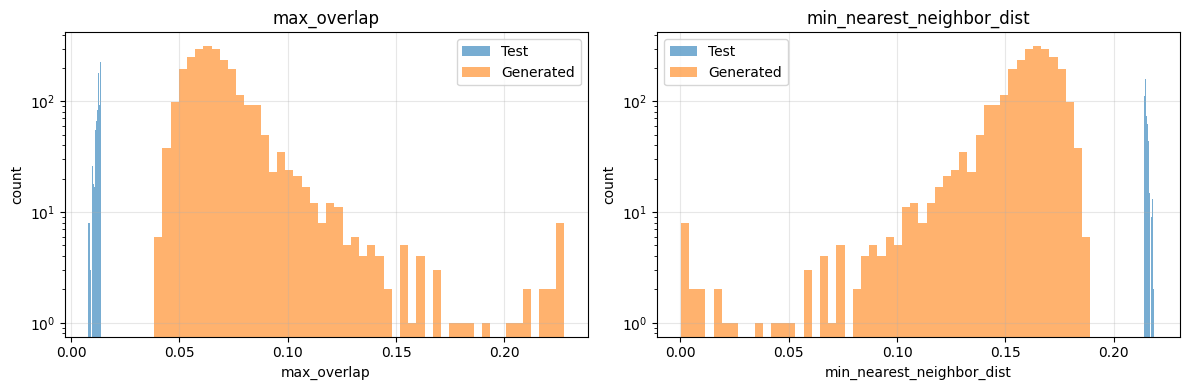

In [8]:
#classic Sampling with ODESolver
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=2500,
    gen_batch_size=50,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=2500  mean=0.012452  std=0.000998  min=0.007936  max=0.013625
  Generated-> n=2500  mean=0.039097  std=0.005536  min=0.022019  max=0.072401
[min_nearest_neighbor_dist]
  Test     -> n=2500  mean=0.215088  std=0.000998  min=0.213914  max=0.219603
  Generated-> n=2500  mean=0.188443  std=0.005536  min=0.155139  max=0.205520


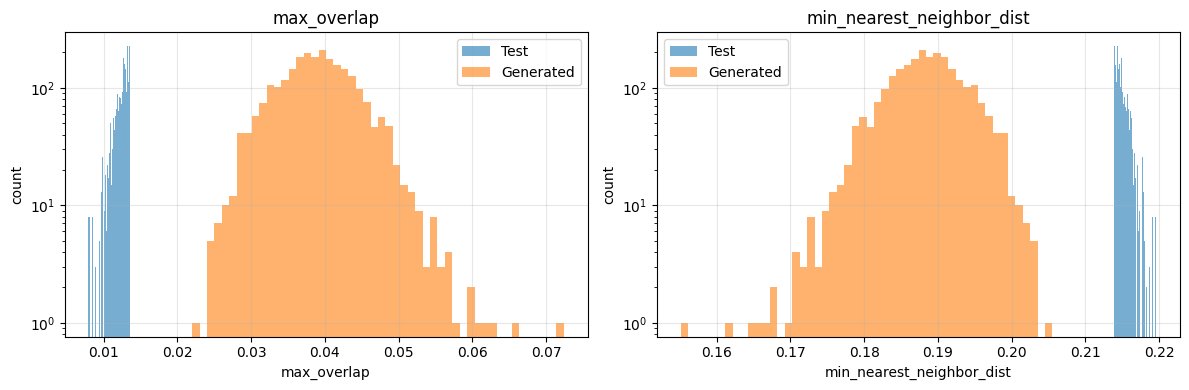

In [92]:
#Sampling with PCFM v1
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=2500,
    gen_batch_size=50,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=2500  mean=0.012452  std=0.000998  min=0.007936  max=0.013625
  Generated-> n=2500  mean=0.036047  std=0.006639  min=0.020477  max=0.055732
[min_nearest_neighbor_dist]
  Test     -> n=2500  mean=0.215088  std=0.000998  min=0.213914  max=0.219603
  Generated-> n=2500  mean=0.191492  std=0.006639  min=0.171807  max=0.207062


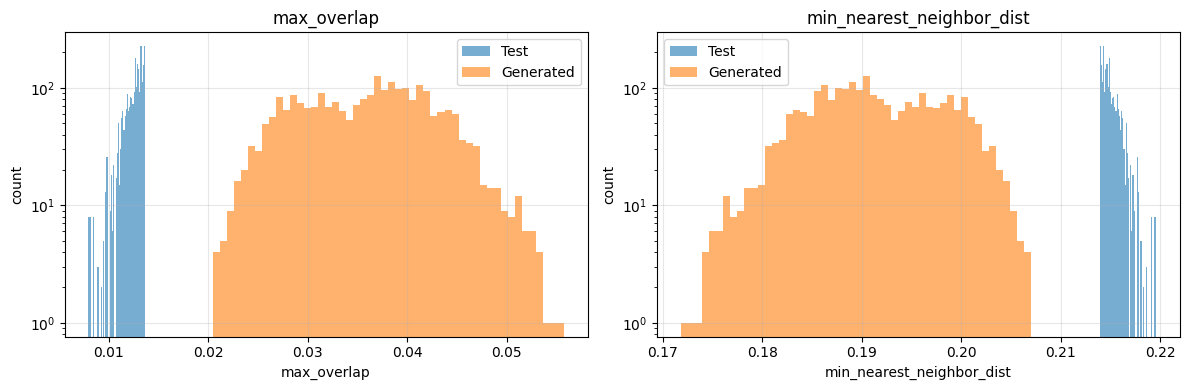

In [98]:
#Sampling with PCFM v2 (BEST)
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=2500,
    gen_batch_size=50,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)